# Dynamic plotting for revised plus_base experiments

Notebook ini membaca output terbaru dari folder `plus_base`, sehingga grafik tidak lagi memakai angka hard-coded dari hasil lama.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

BASE_PROJECT = Path("/content/drive/MyDrive/New Jurnal Cross")

UTTER_DIR = BASE_PROJECT / "results_lodo_utterance_fusion_plus_base"
SEQ_DIR = BASE_PROJECT / "results_lodo_sequence_cross_attention_plus_base"
FIG_DIR = BASE_PROJECT / "figures_plus_base"
FIG_DIR.mkdir(parents=True, exist_ok=True)

COMPARE_TABLE = SEQ_DIR / "compare_lodo_all_models_paper_table.csv"

print("COMPARE_TABLE:", COMPARE_TABLE, COMPARE_TABLE.exists())
print("FIG_DIR:", FIG_DIR)

COMPARE_TABLE: /content/drive/MyDrive/New Jurnal Cross/results_lodo_sequence_cross_attention_plus_base/compare_lodo_all_models_paper_table.csv True
FIG_DIR: /content/drive/MyDrive/New Jurnal Cross/figures_plus_base


In [3]:
def parse_mean_std(value):
    """Parse strings like '83.70 ± 0.61' into numeric mean and std."""
    if pd.isna(value):
        return np.nan, np.nan

    text = str(value).strip()
    parts = re.split(r"\s*±\s*", text)

    if len(parts) == 1:
        return float(parts[0]), np.nan

    return float(parts[0]), float(parts[1])


def load_compare_table(path=COMPARE_TABLE):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    df = pd.read_csv(path)

    # Expected columns:
    # Model, Held-out Test Dataset, Accuracy, UAR, Macro-F1, Weighted-F1
    required = ["Model", "Held-out Test Dataset", "Macro-F1"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in compare table: {missing}")

    parsed = df["Macro-F1"].apply(parse_mean_std)
    df["macro_f1_mean"] = parsed.apply(lambda x: x[0])
    df["macro_f1_std"] = parsed.apply(lambda x: x[1])

    return df


compare_df = load_compare_table()
display(compare_df)

,Model,Held-out Test Dataset,Accuracy,UAR,Macro-F1,Weighted-F1,macro_f1_mean,macro_f1_std
0,Handcrafted SVM-RBF,EMODB,27.30 ± 0.00,25.84 ± 0.00,19.74 ± 0.00,20.60 ± 0.00,19.74,0.00
1,Handcrafted SVM-RBF,RAVDESS,22.16 ± 0.00,20.31 ± 0.00,14.16 ± 0.00,15.44 ± 0.00,14.16,0.00
2,Handcrafted SVM-RBF,RESD,23.46 ± 0.00,24.60 ± 0.00,22.59 ± 0.00,22.32 ± 0.00,22.59,0.00
3,Handcrafted MLP,EMODB,28.51 ± 0.85,27.02 ± 1.13,19.80 ± 1.43,20.31 ± 1.59,19.80,1.43
4,Handcrafted MLP,RAVDESS,25.95 ± 2.55,23.78 ± 2.34,16.27 ± 3.11,17.75 ± 3.39,16.27,3.11
5,Handcrafted MLP,RESD,23.76 ± 0.05,24.61 ± 0.34,22.77 ± 0.71,22.75 ± 0.84,22.77,0.71
6,emotion2vec MLP,EMODB,83.98 ± 0.50,83.81 ± 0.52,83.52 ± 0.52,83.63 ± 0.55,83.52,0.52
7,emotion2vec MLP,RAVDESS,94.73 ± 0.39,94.99 ± 0.28,94.52 ± 0.42,94.76 ± 0.38,94.52,0.42
8,emotion2vec MLP,RESD,59.38 ± 0.27,58.43 ± 0.41,59.31 ± 0.34,59.63 ± 0.26,59.31,0.34
9,Concat Fusion MLP,EMODB,83.19 ± 0.98,83.07 ± 1.07,82.60 ± 1.19,82.72 ± 1.12,82.60,1.19


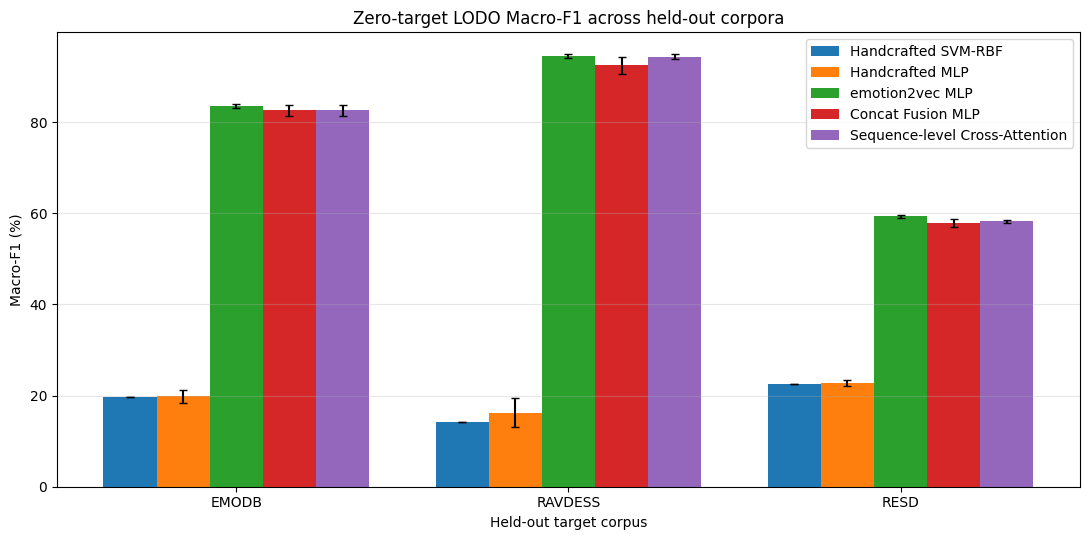

Saved: /content/drive/MyDrive/New Jurnal Cross/figures_plus_base/lodo_macro_f1_all_models_plus_base.png
Saved: /content/drive/MyDrive/New Jurnal Cross/figures_plus_base/lodo_macro_f1_all_models_plus_base.pdf


In [4]:
# ============================================================
# Figure: LODO Macro-F1 by model and held-out dataset
# ============================================================

df = compare_df.copy()
models = df["Model"].drop_duplicates().tolist()
datasets = df["Held-out Test Dataset"].drop_duplicates().tolist()

x = np.arange(len(datasets))
width = 0.8 / max(len(models), 1)

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, model in enumerate(models):
    sub = df[df["Model"] == model].set_index("Held-out Test Dataset").reindex(datasets)
    offset = (i - (len(models) - 1) / 2) * width

    ax.bar(
        x + offset,
        sub["macro_f1_mean"].values,
        width,
        yerr=sub["macro_f1_std"].values,
        capsize=3,
        label=model
    )

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("Macro-F1 (%)")
ax.set_xlabel("Held-out target corpus")
ax.set_title("Zero-target LODO Macro-F1 across held-out corpora")
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

png_path = FIG_DIR / "lodo_macro_f1_all_models_plus_base.png"
pdf_path = FIG_DIR / "lodo_macro_f1_all_models_plus_base.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

,Model,average_macro_f1,std_across_folds
4,emotion2vec MLP,79.116667,18.013274
3,Sequence-level Cross-Attention,78.390000,18.438837
0,Concat Fusion MLP,77.630000,17.871058
1,Handcrafted MLP,19.613333,3.254018
2,Handcrafted SVM-RBF,18.830000,4.288042


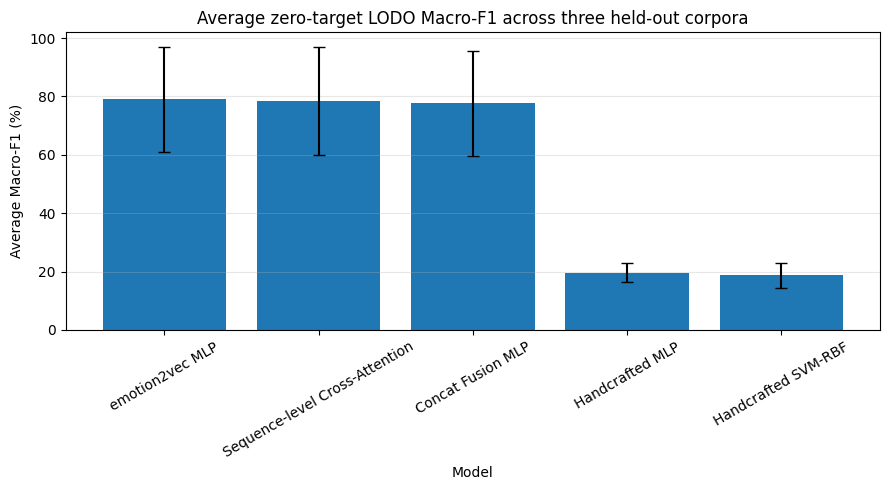

Saved: /content/drive/MyDrive/New Jurnal Cross/figures_plus_base/average_lodo_macro_f1_plus_base.png
Saved: /content/drive/MyDrive/New Jurnal Cross/figures_plus_base/average_lodo_macro_f1_plus_base.pdf


In [5]:
# ============================================================
# Optional: average LODO Macro-F1 across the three held-out corpora
# ============================================================

avg_df = (
    compare_df
    .groupby("Model", as_index=False)
    .agg(
        average_macro_f1=("macro_f1_mean", "mean"),
        std_across_folds=("macro_f1_mean", "std")
    )
    .sort_values("average_macro_f1", ascending=False)
)

display(avg_df)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    avg_df["Model"],
    avg_df["average_macro_f1"],
    yerr=avg_df["std_across_folds"],
    capsize=4
)

ax.set_ylabel("Average Macro-F1 (%)")
ax.set_xlabel("Model")
ax.set_title("Average zero-target LODO Macro-F1 across three held-out corpora")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

png_path = FIG_DIR / "average_lodo_macro_f1_plus_base.png"
pdf_path = FIG_DIR / "average_lodo_macro_f1_plus_base.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

In [6]:
# ============================================================
# Optional: combine per-class F1 tables if available
# ============================================================

utter_per_class = UTTER_DIR / "lodo_paper_table_per_class_f1.csv"
seq_per_class = SEQ_DIR / "lodo_sequence_xattn_paper_table_per_class_f1.csv"

print("Utterance per-class table:", utter_per_class, utter_per_class.exists())
print("Sequence per-class table :", seq_per_class, seq_per_class.exists())

if utter_per_class.exists():
    utter_df = pd.read_csv(utter_per_class)
    display(utter_df.head())

if seq_per_class.exists():
    seq_df = pd.read_csv(seq_per_class)
    display(seq_df.head())

Utterance per-class table: /content/drive/MyDrive/New Jurnal Cross/results_lodo_utterance_fusion_plus_base/lodo_paper_table_per_class_f1.csv True
Sequence per-class table : /content/drive/MyDrive/New Jurnal Cross/results_lodo_sequence_cross_attention_plus_base/lodo_sequence_xattn_paper_table_per_class_f1.csv True


,Model,Held-out Dataset,angry,disgust,fear,happy,neutral,sad
0,Handcrafted SVM-RBF,EMODB,56.34 ± 0.00,27.96 ± 0.00,8.42 ± 0.00,9.95 ± 0.00,12.59 ± 0.00,3.15 ± 0.00
1,Handcrafted SVM-RBF,RAVDESS,34.91 ± 0.00,21.76 ± 0.00,25.23 ± 0.00,1.00 ± 0.00,0.00 ± 0.00,2.04 ± 0.00
2,Handcrafted SVM-RBF,RESD,30.94 ± 0.00,31.64 ± 0.00,19.20 ± 0.00,10.75 ± 0.00,17.86 ± 0.00,25.14 ± 0.00
3,Handcrafted MLP,EMODB,51.14 ± 3.08,30.74 ± 3.17,5.97 ± 5.46,5.52 ± 2.85,20.94 ± 2.32,4.49 ± 5.03
4,Handcrafted MLP,RAVDESS,38.17 ± 1.18,31.66 ± 8.71,18.31 ± 3.33,0.00 ± 0.00,0.00 ± 0.00,9.48 ± 12.91


,Model,Held-out Dataset,angry,disgust,fear,happy,neutral,sad
0,Sequence-level Cross-Attention,EMODB,86.12 ± 1.06,80.69 ± 2.10,73.81 ± 2.53,82.17 ± 0.77,85.60 ± 2.21,87.01 ± 0.65
1,Sequence-level Cross-Attention,RAVDESS,96.78 ± 0.36,97.88 ± 0.27,93.27 ± 1.07,95.24 ± 0.63,91.74 ± 0.90,91.37 ± 1.06
2,Sequence-level Cross-Attention,RESD,63.32 ± 0.45,57.69 ± 1.08,56.22 ± 0.41,65.87 ± 1.23,59.94 ± 1.77,46.32 ± 1.41
